In [1]:
from sklearn.datasets import load_iris 
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [2]:
data = load_iris()

In [3]:
df = pd.DataFrame(data.data,columns=data.feature_names)

In [4]:
 data.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [5]:
df["target"] = data.target

In [6]:
df["target"].value_counts()

target
0    50
1    50
2    50
Name: count, dtype: int64

In [7]:
df0 = df[df["target"]==0]
df1 = df[df["target"]==1]
df2 = df[df["target"]==2]

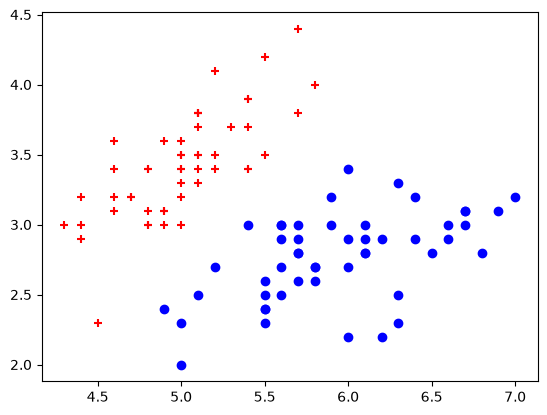

In [8]:
plt.scatter(df0["sepal length (cm)"],df0["sepal width (cm)"],marker = "+",color = "red")
plt.scatter(df1["sepal length (cm)"],df1["sepal width (cm)"],marker = "o",color = "b")
plt.show()

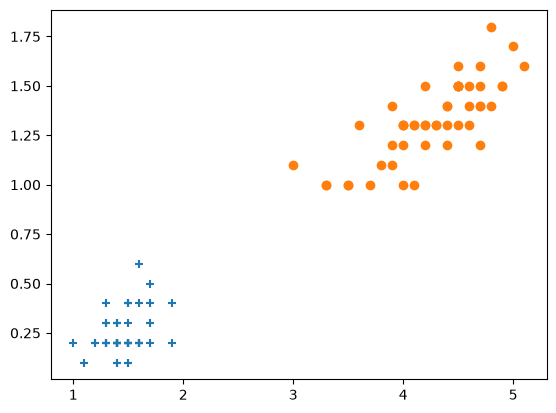

In [9]:
plt.scatter(df0["petal length (cm)"],df0["petal width (cm)"],marker = "+")
plt.scatter(df1["petal length (cm)"],df1["petal width (cm)"],marker = "o")
plt.show()

In [10]:
x = df.drop(columns = "target")
y = df["target"]

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

In [12]:
x_train,x_test , y_train , y_test = train_test_split(x,y,test_size=0.2,
                                                    random_state=88)

In [13]:
sm = SVC()

In [14]:
sm.fit(x_train,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [15]:
print("Train accuracy",sm.score(x_train,y_train))
print("Test accuracy",sm.score(x_test,y_test))

Train accuracy 0.95
Test accuracy 1.0


In [16]:
pickle.dump(sm, open("iris_model.pkl", "wb"))

In [17]:
import streamlit as st

st.title("🌸 Iris Flower Prediction App")

st.header("Enter Flower Details")

sepal_length = st.number_input("Sepal Length")
sepal_width = st.number_input("Sepal Width")
petal_length = st.number_input("Petal Length")
petal_width = st.number_input("Petal Width")

if st.button("Predict"):
    st.success("Prediction Done")

2026-07-17 13:35:12.129 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-17 13:35:12.953 
  command:

    streamlit run C:\Users\HP\AppData\Roaming\Python\Python311\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-07-17 13:35:12.954 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-17 13:35:12.954 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-17 13:35:12.955 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-17 13:35:12.955 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-17 13:35:12.958 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-17 13:35:12.958 Thread 

In [18]:
import streamlit as st
import pickle
import numpy as np

# Load Model
model = pickle.load(open("iris_model.pkl", "rb"))

st.title("🌸 Iris Flower Prediction")

sl = st.number_input("Sepal Length")
sw = st.number_input("Sepal Width")
pl = st.number_input("Petal Length")
pw = st.number_input("Petal Width")

if st.button("Predict"):

    data = np.array([[sl, sw, pl, pw]])

    prediction = model.predict(data)

    if prediction[0] == 0:
        st.success("Setosa")

    elif prediction[0] == 1:
        st.success("Versicolor")

    else:
        st.success("Virginica")

2026-07-17 13:35:13.042 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-17 13:35:13.045 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-17 13:35:13.045 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-17 13:35:13.047 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-17 13:35:13.047 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-17 13:35:13.048 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-17 13:35:13.048 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-17 13:35:13.049 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

# svm

In [ ]:
support vector machine